### Load and Modify Configuration File

In [1]:
from configs.config_loader import load_config
config = load_config('configs/default.yaml')

version : default
seed : 1
x_domain : [-1, 1]
t_domain : [0, 1.0]
N_col : 1024
N_IC : 128
N_BC : 128
N_hidden : 6
N_neurons : 100
activation : tanh
N_epochs : 50000
learning_rate : 0.001
decay_rate : 1.0
freq_log : 10
freq_print : 100
keys_print : ['loss_data', 'loss_IC', 'loss_BC', 'loss_AC']
freq_save : 1000
regularization : reg_derivative
reg_coeff : 1000
reg_decay : linear
reg_epochs : 0.25


### Initialize Physics-Informed Neural Network

In [2]:
from model.neural_net import PhysicsInformedNN
PINN = PhysicsInformedNN(config, verbose=True)

2024-10-31 18:45:26.419115: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2024-10-31 18:45:26.458095: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2024-10-31 18:45:26.459098: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2024-10-31 18:45:27.122942: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


Model: "PhysicsInformedNN"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 100)               300       
                                                                 
 dense_1 (Dense)             (None, 100)               10100     
                                                                 
 dense_2 (Dense)             (None, 100)               10100     
                                                                 
 dense_3 (Dense)             (None, 100)               10100     
                                                                 
 dense_4 (Dense)             (None, 100)               10100     
                                                                 
 dense_5 (Dense)             (None, 100)               10100     
                                                                 
 dense_6 (Dense)             (None, 1)           

### Train Physics-Informed Neural Network

In [3]:
training_logs = PINN.train()

Training started...
    0/50000 | loss_IC: 1.52e-01 | loss_BC: 3.83e-03 | loss_AC: 9.94e+02
  100/50000 | loss_IC: 2.14e-01 | loss_BC: 6.73e-02 | loss_AC: 3.23e+01
  200/50000 | loss_IC: 2.12e-01 | loss_BC: 6.28e-02 | loss_AC: 3.13e+01
  300/50000 | loss_IC: 1.65e-01 | loss_BC: 3.24e-01 | loss_AC: 3.46e+01
  400/50000 | loss_IC: 1.31e-01 | loss_BC: 4.42e-01 | loss_AC: 3.38e+01
  500/50000 | loss_IC: 1.12e-01 | loss_BC: 4.44e-01 | loss_AC: 3.37e+01
  600/50000 | loss_IC: 1.39e-01 | loss_BC: 3.08e-01 | loss_AC: 3.02e+01
  700/50000 | loss_IC: 1.13e-01 | loss_BC: 3.24e-01 | loss_AC: 3.26e+01
  800/50000 | loss_IC: 1.24e-01 | loss_BC: 2.18e-01 | loss_AC: 3.25e+01
  900/50000 | loss_IC: 1.01e-01 | loss_BC: 7.98e-02 | loss_AC: 3.32e+01
 1000/50000 | loss_IC: 8.94e-02 | loss_BC: 2.43e-01 | loss_AC: 3.50e+01
 1100/50000 | loss_IC: 1.51e-01 | loss_BC: 6.78e-02 | loss_AC: 2.96e+01
 1200/50000 | loss_IC: 1.17e-01 | loss_BC: 5.39e-02 | loss_AC: 3.13e+01
 1300/50000 | loss_IC: 1.63e-01 | loss_BC: 1

# Plot Section

In [4]:
from model.plots import learning_curves, allen_cahn_mesh, allen_cahn_xcut

### Learning Curves

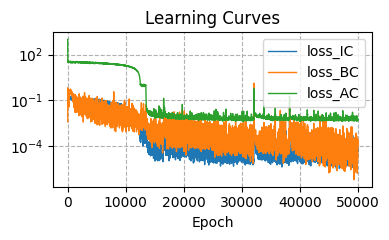

In [5]:
learning_curves(training_logs)

### Allen-Cahn Dynamics (Mesh)

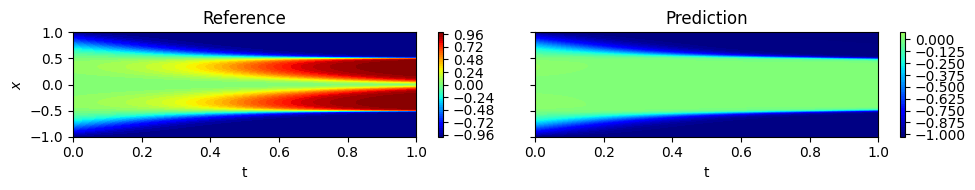

In [6]:
allen_cahn_mesh(PINN)

### Allen-Cahn Dynamics (x-Cut)

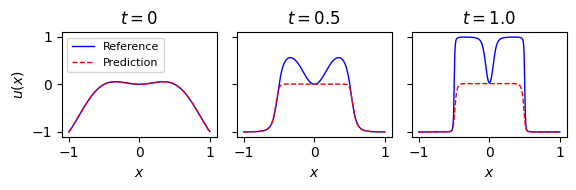

In [7]:
allen_cahn_xcut(PINN, time_steps=[0, 0.5, 1.0])

(1024,)
0.52387935


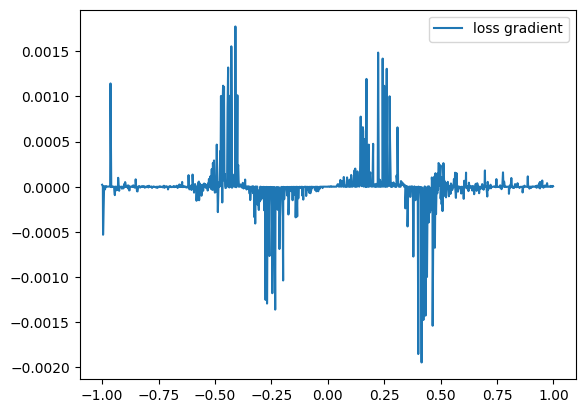

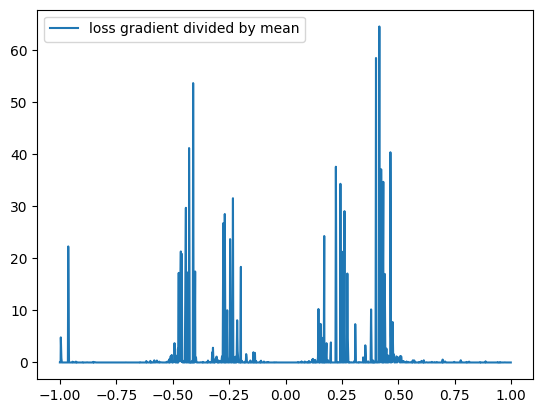

In [8]:
import tensorflow as tf
import numpy as np
from matplotlib import pyplot as plt

# Reference data and PINN prediction
X_col = PINN.data.collocation() 

with tf.GradientTape() as tape:  
    tape.watch(X_col)      
    physics_loss = PINN.loss.allen_cahn(X_col, 0)
physics_loss_grad = tape.gradient(physics_loss, X_col)

ind = np.argsort(X_col[:, 0])

print(np.take(X_col, ind, axis=0)[:, 0].shape)
time_grad_physics_loss = np.take(physics_loss_grad, ind, axis=0)[:, 0]
normed_loss = (time_grad_physics_loss - np.min(time_grad_physics_loss)) / (np.max(time_grad_physics_loss) - np.min(time_grad_physics_loss))
print(np.mean(np.mean(normed_loss)))

# print(X_col[ind])
plt.figure()
plt.plot(np.take(X_col, ind, axis=0)[:, 0], np.take(physics_loss_grad, ind, axis=0)[:, 0], label="loss gradient")
plt.legend()
plt.show()

plt.figure()
plt.plot(np.take(X_col, ind, axis=0)[:, 0], np.take(physics_loss_grad, ind, axis=0)[:, 0]**2 / np.mean(np.take(physics_loss_grad, ind, axis=0)[:, 0]**2), label="loss gradient divided by mean")
plt.legend()
plt.show()

### Training animation

In [9]:
import matplotlib.pyplot as plt
import numpy as np
import os
from matplotlib.animation import FuncAnimation, FFMpegWriter
from IPython.display import HTML



def init_fig():

    fig, axes = plt.subplots(1, 2, sharex=True, sharey=True,
                             figsize=(10, 2))

    #############################
    ### Initial plot comes here
    #############################

    plt.tight_layout()
    plt.close(fig)
    return fig, axes


def animate(i, *fargs):
    # get passed arguments
    axes = fargs[0]
    N_times = fargs[1]

    # print status of animation
    print(f'Processed: {i/N_times*100:.0f}%', end='\r')

    # clear axis
    axes[0].clear()
    axes[1].clear()
    #############################
    ### load model weights & make predictions
    #############################
    flag = i * config['freq_save']
    PINN.load_weights(PINN.log_path.joinpath(f'model_weights/weights_{flag}.pkl'))

    ############################
    # Prediciton plot
    ############################
    
    # get reference data and make prediction
    X_ref, u_ref = PINN.data.reference_mesh()
    u_pred = PINN(X_ref)

    # properties for tricontourf plot
    props = {'cmap': 'jet', 'levels': 50, 'vmin': -1, 'vmax': 1}
    # Reference
    axes[0].set_title('Reference')
    contf = axes[0].tricontourf(X_ref[:,1], X_ref[:,0], u_ref[:,0], **props)
    if i == 0:
        fig.colorbar(contf, ax=axes[0])

    # Prediction
    axes[1].set_title('Prediction')
    contf = axes[1].tricontourf(X_ref[:,1], X_ref[:,0], u_pred[:,0], **props)
    if i == 0:
        fig.colorbar(contf, ax=axes[1])
    
    ##############################
    ### Regularization coefficient
    ##############################
    epoch = flag
    # coeff = config["reg_coeff"] * (float(config["reg_decay"])**epoch)
    coeff = config["reg_coeff"] * (1 - epoch / config["reg_epochs"])
    if epoch > (config["reg_epochs"] * config["N_epochs"]):
        coeff = 0
    
    axes[1].plot([], [], c='black', lw=1, label=f'regularization coeff {coeff}')

    # Axis appearance
    axes[0].set_yticks([-1, -0.5, 0, 0.5, 1.0])
    axes[0].set_ylabel(r'$x$')
    for ax in axes:
        ax.set_xlabel(r't')

    plt.tight_layout()


# should equal the number of saved weights files
N_frames = int(config["N_epochs"] / config["freq_save"])

(fig, ax) = init_fig()
ani = FuncAnimation(fig, animate, frames=N_frames, fargs=(ax, N_frames))
HTML(ani.to_jshtml())

<Figure size 640x480 with 0 Axes>